In [8]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df_panel = pd.read_csv(r'd:\GG\output\eventstudy_pseudopanel.csv')
df_panel['month_period'] = pd.to_datetime(df_panel['month_period']).dt.to_period('M')

df_shocks = pd.read_csv(r'd:\GG\output\shocks_panel_wave_sendwave_gambia.csv')

# Define Estimation Parameters
bandwidth_months = 12 

Event: wave_bceao_eme_license (2022-04)
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           50.6577      1.351     37.489      0.000      48.009      53.306
t_centered          -0.3551      0.188     -1.884      0.060      -0.724       0.014
After               -1.4246      1.611     -0.884      0.377      -4.583       1.734
t_centered:After     0.7322      0.247      2.963      0.003       0.248       1.217

Joint Significance (Jump & Trend Change): F=11.5453, p=0.0031



d:\GG\.venv\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


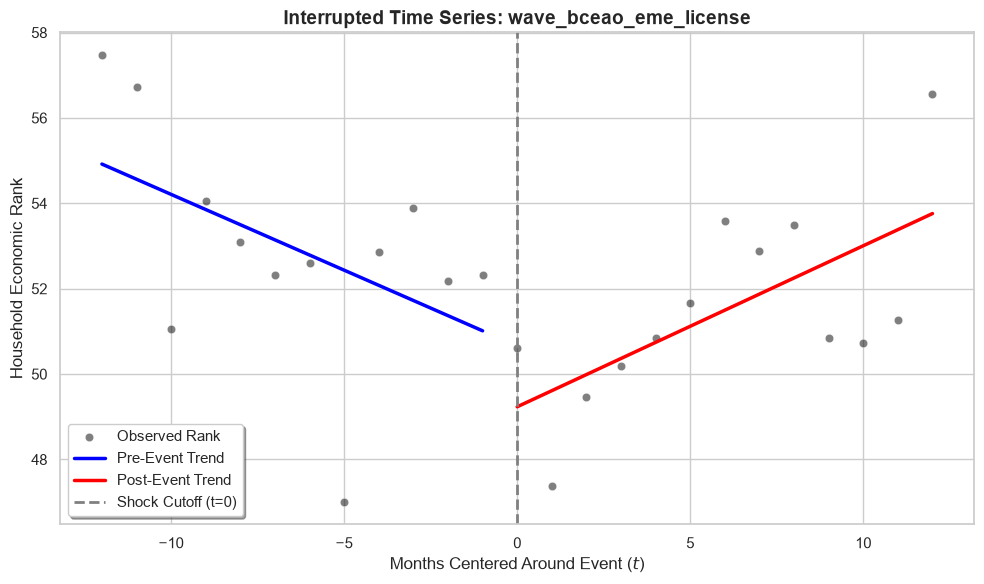

Event: wave_staff_cut_15pct (2022-06)
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           50.0730      1.356     36.926      0.000      47.415      52.731
t_centered          -0.2369      0.166     -1.430      0.153      -0.562       0.088
After                1.0769      1.649      0.653      0.514      -2.155       4.308
t_centered:After     0.3255      0.260      1.251      0.211      -0.184       0.836

Joint Significance (Jump & Trend Change): F=1.8659, p=0.3934



d:\GG\.venv\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


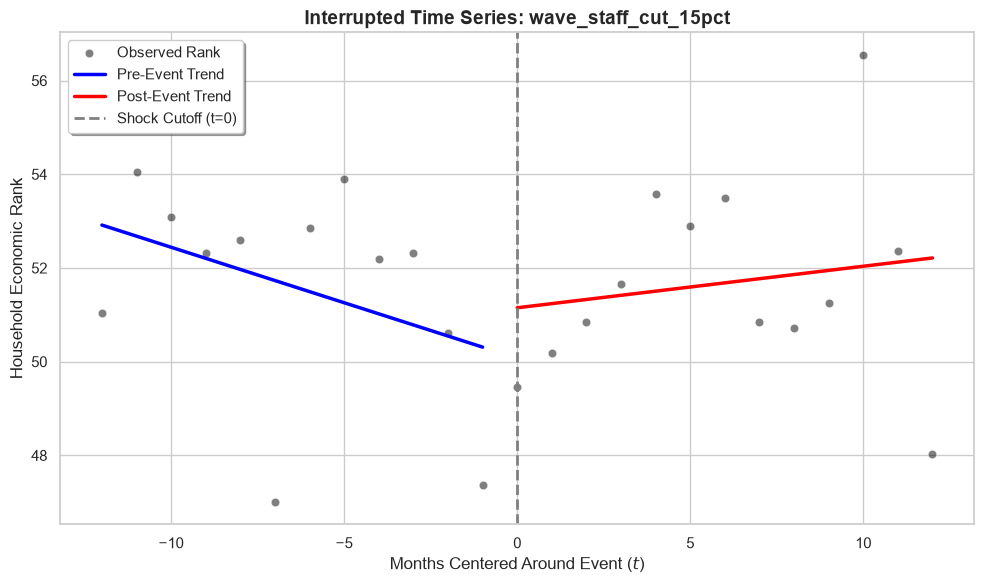

Event: wave_debt_financing_91m (2022-07)


d:\GG\.venv\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           49.2342      0.975     50.511      0.000      47.324      51.145
t_centered          -0.3456      0.116     -2.988      0.003      -0.572      -0.119
After                2.8384      1.310      2.167      0.030       0.271       5.406
t_centered:After     0.2837      0.207      1.374      0.170      -0.121       0.688

Joint Significance (Jump & Trend Change): F=7.3914, p=0.0248



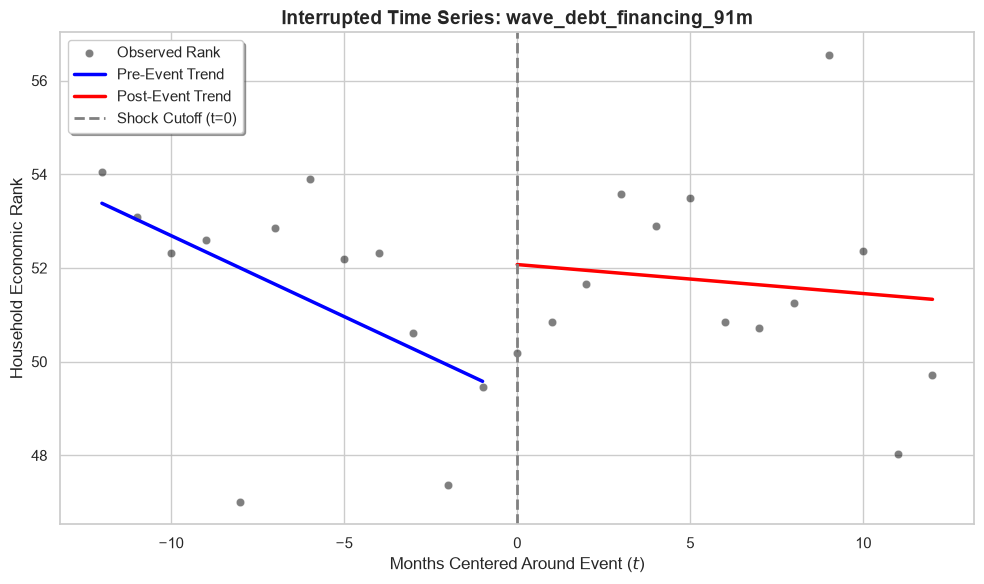

Event: wave_gambia_launch (2022-09)
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           49.6549      0.903     54.985      0.000      47.885      51.425
t_centered          -0.2025      0.153     -1.320      0.187      -0.503       0.098
After                3.7697      1.143      3.297      0.001       1.529       6.011
t_centered:After    -0.1277      0.185     -0.689      0.491      -0.491       0.236

Joint Significance (Jump & Trend Change): F=14.0586, p=0.0009



d:\GG\.venv\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


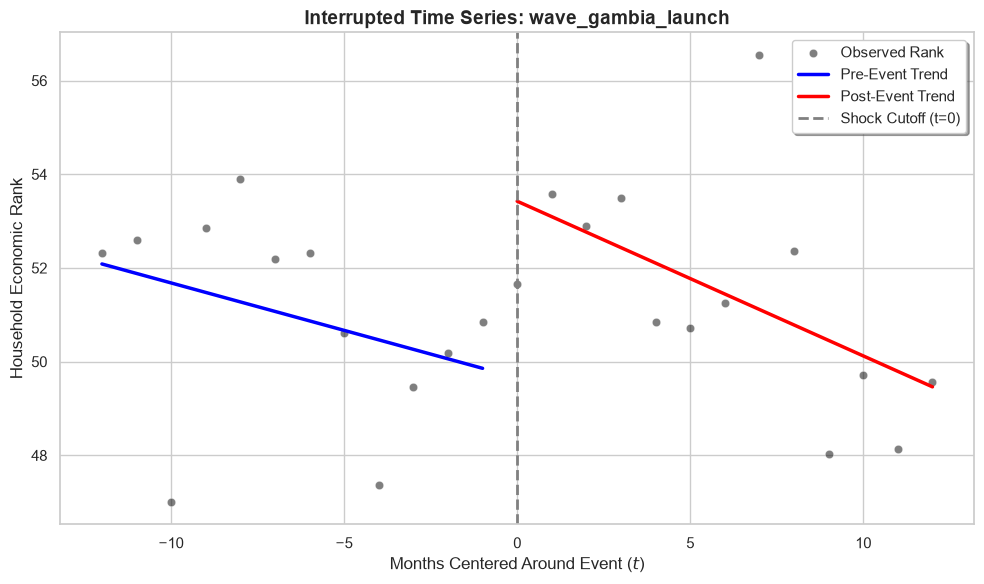

Event: zepz_funding_267m (2024-10)
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           52.3582      7.645      6.849      0.000      37.374      67.342
t_centered           0.0435      0.861      0.051      0.960      -1.643       1.730
After                1.6907      7.680      0.220      0.826     -13.361      16.743
t_centered:After    -0.2928      0.873     -0.336      0.737      -2.003       1.418

Joint Significance (Jump & Trend Change): F=3.8836, p=0.1434



d:\GG\.venv\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


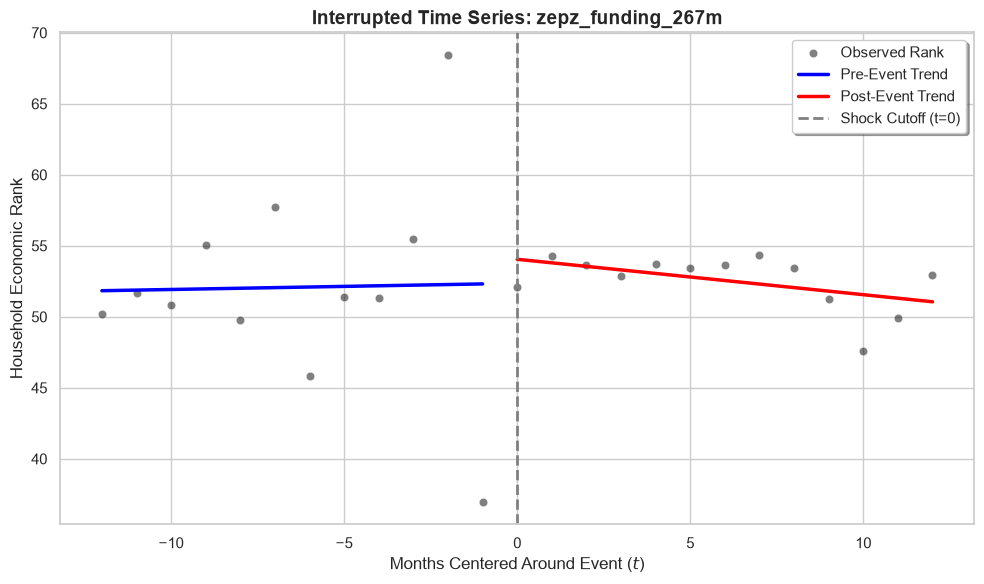

Event: wave_expansion_funding_137m (2025-07)
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           52.8781      2.427     21.786      0.000      48.121      57.635
t_centered          -0.1009      0.676     -0.149      0.881      -1.426       1.224
After               -2.1410      2.677     -0.800      0.424      -7.387       3.105
t_centered:After     0.4687      0.691      0.678      0.498      -0.886       1.823


d:\GG\.venv\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(



Joint Significance (Jump & Trend Change): F=5.3435, p=0.0691



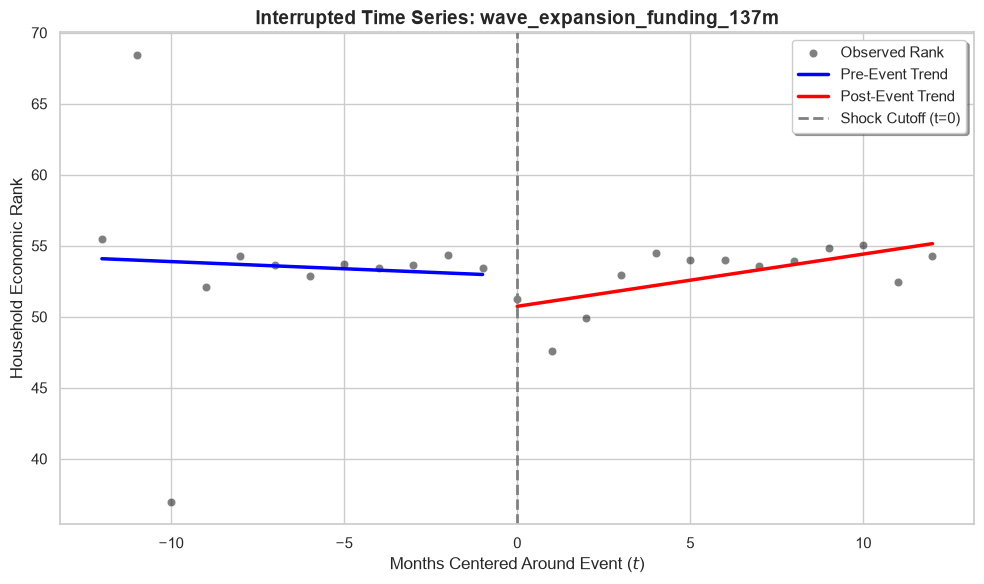

In [10]:
sns.set_theme(style="whitegrid")

for idx, row in df_shocks.iterrows():
    shock_name = row['shock_name']
    cutoff = pd.Period(year=int(row['shock_year']), month=int(row['shock_month']), freq='M')
    
    # Restrict to Event Window
    df_local = df_panel.copy()
    df_local['t_centered'] = (df_local['month_period'] - cutoff).apply(lambda x: x.n)
    df_local = df_local[(df_local['t_centered'] >= -bandwidth_months) & (df_local['t_centered'] <= bandwidth_months)].copy()
    
    if df_local.empty or len(df_local) < 4:
        print(f"[{shock_name}] Insufficient data in window.\n")
        continue

    # Define Treatment
    df_local['After'] = (df_local['t_centered'] >= 0).astype(int)
    
    try:
        # Fit Model
        model = smf.ols('hh_econ_rank ~ t_centered + After + t_centered:After', data=df_local)
        results = model.fit(cov_type='HC1')
        
        # 1. Print Statistical Results
        print(f"{'='*60}\nEvent: {shock_name} ({cutoff})\n{'='*60}")
        print(results.summary().tables[1])
        
        joint_test = results.wald_test('(After = 0), (t_centered:After = 0)')
        print(f"\nJoint Significance (Jump & Trend Change): F={joint_test.statistic[0][0]:.4f}, p={joint_test.pvalue:.4f}\n")
        
        # 2. Visualization
        plt.figure(figsize=(10, 6))
        
        # Scatter of actual observations
        sns.scatterplot(x='t_centered', y='hh_econ_rank', data=df_local, color='black', alpha=0.5, label='Observed Rank')
        
        # Split data for plotting regression lines
        pre_data = df_local[df_local['After'] == 0].sort_values('t_centered')
        post_data = df_local[df_local['After'] == 1].sort_values('t_centered')
        
        # Plot Pre-Trend Line
        plt.plot(pre_data['t_centered'], results.predict(pre_data), color='blue', linewidth=2.5, label='Pre-Event Trend')
        
        # Plot Post-Trend Line
        plt.plot(post_data['t_centered'], results.predict(post_data), color='red', linewidth=2.5, label='Post-Event Trend')
        
        # Cutoff Demarcation
        plt.axvline(x=0, color='gray', linestyle='--', linewidth=2, label='Shock Cutoff (t=0)')
        
        # Plot Aesthetics
        plt.title(f"Interrupted Time Series: {shock_name}", fontsize=14, fontweight='bold')
        plt.xlabel("Months Centered Around Event ($t$)", fontsize=12)
        plt.ylabel("Household Economic Rank", fontsize=12)
        plt.legend(frameon=True, shadow=True)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"[{shock_name}] Estimation failed: {e}\n")